In [191]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from dotenv import load_dotenv
from IPython.display import display, Image
import gradio as gr
import requests
import os
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_core.tools import Tool
from langchain_core.messages import HumanMessage, SystemMessage


In [192]:
load_dotenv(override=True)


True

In [193]:
from langchain_community.utilities import GoogleSerperAPIWrapper

serper = GoogleSerperAPIWrapper()
serper.run("¿Cual fua el marcador del ultimo partido del mundia 2026?")

"México gana por la mínima ante Corea del Sur con gol de Luis Romo (50') tras un error de Kim Seung-gyu y asegura su lugar en la siguiente ronda ... La ganadora del encuentro fue España, que conquistó el título luego de vencer 1-0 en tiempo extra a la campeona defensora Argentina, el partido fue definido con ... España se coronó campeona del mundo al vencer 1-0 a Argentina en la final de la Copa del Mundo 2026, disputada en territorio norteamericano. Ve los marcadores de los 104 partidos y las 48 selecciones, y cómo terminó la calificación en los sectores A, B, C, D, E, F, G, H, I, J, K y L. Final, 1-0, Final del partido, Estadio Nueva York/Nueva Jersey, 2026-07-19T15:00:00Z. Final 19:00 España Argentina 1 0. Grupo 2 18:30 Argentina Consulta los horarios y resultados de los partidos de Final de la Mundial 2026 en AS.com. Domingo 19 de Julio Finalizado España 1 - 0 Argentina LLUVIA DE GOLES: INGLATERRA LE GANÓ 6-4 A FRANCIA y SE QUEDÓ con el 3ER PUESTO⚽ MUNDIAL 2026 EN VIVO ... France v

In [194]:

#import from langchain.core.tools import Tool
tool_search_google = Tool(
    name="Google Search",
    func=serper.run,
    description="Useful for when you need to answer questions about current events.")
    

In [195]:
tool_search_google.invoke("¿Noticias recientes sobre el PGA Tour?")

"Latest golf news from PGA TOUR, PGA TOUR Champions, KornFerry TOUR. 2026 PGA TOUR this week: Rocket Classic facts and figures. Can Johnny Keefer make noise at ... Últimas noticias de golf del PGA TOUR, PGA TOUR Champions, Korn Ferry Tour. ... Sobre · Carreras · TPC Network · Contáctenos · TOURCAST · Impacto. Asociaciones. Rickie Fowler opens the week with a 7-under 63. Peter Malnati's 61 was his career-low round on TOUR. Jackson Koivun is capable of chunking Encuentra la cobertura en vivo, resultados y clasificaciones más recientes de los principales circuitos de golf, incluyendo los tours de PGA, LPGA, LIV y TGL. Golf News · Malnati threatens 60 at Rocket Classic with Fowler chasing · Why Koivun made the President Cup selections more difficult · Jackson Koivun bests Scottie ... PGA Tour announced the first Championship Series event – the Travelers Championship, a surprise second tournament was added to the expanding\xa0... Aaron Rai arrasa en el Campeonato de la PGA, primer inglés en

In [196]:
pushover_api_key = os.getenv("PUSH_OVER_API_KEY")
pushover_user = os.getenv("PUSH_OVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"

def push_notification(message: str):
    data = {
        "token": pushover_api_key,
        "user": pushover_user,
        "message": message
    }
    response = requests.post(pushover_url, data=data)
    return response.status_code == 200

In [197]:
tool_push_notification = Tool(
    name="Push Notification",
    func=push_notification,
    description="Sends a push notification to your device using Pushover.")

data = {
        "token": pushover_api_key,
        "user": pushover_user,
        "title": "test de notificacion",
        "message": "Hola Mundo desde Pushover"
    }


tool_push_notification.invoke("hola a todos")

False

In [198]:
tools=[tool_search_google, tool_push_notification]

In [199]:
from typing import Annotated
from langgraph.graph import add_messages

class state(TypedDict):
    messages: Annotated[list, add_messages]


In [200]:
graph_builder = StateGraph(state)

MODEL_NAME = os.getenv("OLLAMA_MODEL", "llama3.2:3b")
OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL", "http://localhost:11434")
AGENT_TEMPERATURE = float(os.getenv("OLLAMA_TEMPERATURE", "0.3"))
EMBEDDING_MODEL = os.getenv("OLLAMA_EMBEDDING_MODEL", "nomic-embed-text")

SYSTEM_PROMPT = """You are a helpful assistant that must use tools when the user asks for current information.
Rules:
1. If the user asks about current events, recent facts, sports results, tournament winners, news, weather, or anything that requires up-to-date information, you MUST call the Google Search tool.
2. Do not answer from memory alone for those questions.
3. After the tool returns data, use that tool output to produce the final answer.
4. If the tool returns information, include the actual information in your response and summarize it clearly in Spanish.
5. If the tool does not return useful data, say that you could not retrieve the information and ask for a more specific query.
"""

llm = ChatOllama(
    model=MODEL_NAME,
    base_url=OLLAMA_BASE_URL,
    temperature=AGENT_TEMPERATURE,
    streaming=False,
    keep_alive="10m",
)
embedding_model = OllamaEmbeddings(model=EMBEDDING_MODEL, base_url=OLLAMA_BASE_URL)
llm_with_tools = llm.bind_tools(tools, tool_choice="auto")


In [201]:
def _looks_like_info_request(text: str) -> bool:
    lowered = text.lower()
    return any(keyword in lowered for keyword in [
        "último", "ultimo", "reciente", "actual", "noticia", "noticias", "marcador",
        "torneo", "golf", "quién ganó", "quien ganó", "quien fue", "cuál fue", "cual fue",
        "hoy", "mañana", "resultado", "actualidad", "estado", "ganó", "gano"
    ])


def _normalize_message(message):
    if hasattr(message, "content"):
        return message
    if isinstance(message, dict):
        role = message.get("role", "user")
        content = message.get("content", "")
        if role == "system":
            return SystemMessage(content=content)
        if role == "assistant":
            return HumanMessage(content=content)
        if role == "tool":
            return HumanMessage(content=content)
        return HumanMessage(content=content)
    return HumanMessage(content=str(message))


def chatbot_response(state: state):
    try:
        messages = state["messages"]
        normalized_messages = [SystemMessage(content=SYSTEM_PROMPT)]
        for message in messages:
            normalized_messages.append(_normalize_message(message))

        response = llm_with_tools.invoke(normalized_messages)

        if getattr(response, "tool_calls", None):
            return {"messages": [response]}

        content = getattr(response, "content", None)
        if isinstance(content, list):
            content = "".join(
                part.get("text", "") if isinstance(part, dict) else str(part)
                for part in content
            )

        if isinstance(content, str) and content.strip():
            return {"messages": [response]}

        if isinstance(response, dict) and response.get("content"):
            return {"messages": [response]}

        return {"messages": [{"role": "assistant", "content": "No pude obtener información útil con la herramienta."}]}
    except Exception as exc:
        return {"messages": [{"role": "assistant", "content": f"No se pudo contactar con Ollama: {exc}"}]}

graph_builder.add_node("chatbot", chatbot_response)
graph_builder.add_node("tools", ToolNode(tools=tools))


In [202]:
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
    {"tools": "tools", END: END},
)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")


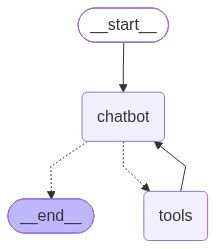

In [203]:
graph=graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [204]:
def chat_with_agent(message, history):
    try:
        user_input = message if isinstance(message, str) else str(message)
        if _looks_like_info_request(user_input):
            user_input = f"Busca información actualizada y usa la herramienta de búsqueda antes de responder: {user_input}"

        result = graph.invoke({"messages": [{"role": "user", "content": user_input}]})
        candidate_messages = None

        if isinstance(result, dict):
            candidate_messages = result.get("messages") or result.get("message")
            if isinstance(candidate_messages, dict):
                candidate_messages = [candidate_messages]

        if not candidate_messages:
            return "No se recibió respuesta del modelo."

        last_message = candidate_messages[-1]
        if hasattr(last_message, "content"):
            content = last_message.content
            if isinstance(content, list):
                content = "".join(
                    part.get("text", "") if isinstance(part, dict) else str(part)
                    for part in content
                )
            return content or "El modelo no devolvió contenido textual."
        if isinstance(last_message, dict):
            return last_message.get("content", "") or "El modelo no devolvió contenido textual."
        return str(last_message)
    except Exception as exc:
        return f"No se pudo procesar la solicitud: {exc}"

gr.ChatInterface(chat_with_agent, title="IA Agent with Tools", description="Chat with an AI agent that can use tools like Google Search and Push Notifications.").launch()


* Running on local URL:  http://127.0.0.1:7873
* To create a public link, set `share=True` in `launch()`.
